# Section 1: Importing Libraries

In [90]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style
style.use('seaborn-v0_8-darkgrid')

# Data preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

# Models
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb

# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score

# Time series
from datetime import datetime
import calendar

# Other utilities
import joblib
from scipy import stats
import shap

# Section 2: Data Loading and Preprocessing

In [91]:
def load_data(file_path):
    """Load and explore the dataset"""
    df = pd.read_csv(file_path)
    
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)
    print(f"Dataset shape: {df.shape}")
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nData types:\n{df.dtypes}")
    print(f"\nFirst 5 rows:")
    print(df.head())
    print(f"\nMissing values:\n{df.isnull().sum()}")
    
    return df

# Load the data
df = load_data('/kaggle/input/alcohol-detection-dataset/alcohol_detection_dataset.csv')

DATASET OVERVIEW
Dataset shape: (30000, 8)

Columns: ['Timestamp', 'Driver_ID', 'Alcohol_Level_ppm', 'Heart_Rate_bpm', 'Movement_Score', 'Temperature_Celsius', 'Humidity_Percent', 'Ambient_Alcohol_ppm']

Data types:
Timestamp               object
Driver_ID               object
Alcohol_Level_ppm      float64
Heart_Rate_bpm         float64
Movement_Score         float64
Temperature_Celsius    float64
Humidity_Percent       float64
Ambient_Alcohol_ppm    float64
dtype: object

First 5 rows:
             Timestamp   Driver_ID  Alcohol_Level_ppm  Heart_Rate_bpm  \
0  2025-04-03 13:02:00   Driver_31           0.023579       70.235791   
1  2025-04-23 10:32:00   Driver_46           0.002552       70.025525   
2  2025-05-07 19:05:00   Driver_29           0.009088       70.090878   
3  2025-06-03 07:03:00   Driver_33           0.004581       70.045815   
4  2025-06-09 00:42:00  Driver_140           0.032259       70.322593   

   Movement_Score  Temperature_Celsius  Humidity_Percent  Ambient_Al

# Section 3: Exploratory Data Analysis (EDA)


DESCRIPTIVE STATISTICS
                       count       mean       std           min        25%  \
Alcohol_Level_ppm    30000.0   0.040161  0.061882  3.554550e-07   0.013488   
Heart_Rate_bpm       30000.0  70.401610  0.618820  7.000000e+01  70.134885   
Movement_Score       30000.0  50.401610  0.618820  5.000000e+01  50.134885   
Temperature_Celsius  30000.0  20.072670  5.766155  1.000070e+01  15.067513   
Humidity_Percent     30000.0  49.987857  5.753819  4.000098e+01  45.024029   
Ambient_Alcohol_ppm  30000.0   0.040258  0.065912  5.290072e-07   0.012324   

                           50%        75%        max  
Alcohol_Level_ppm     0.026728   0.040365   0.399897  
Heart_Rate_bpm       70.267280  70.403648  73.998975  
Movement_Score       50.267280  50.403648  53.998975  
Temperature_Celsius  20.110237  25.037909  30.644294  
Humidity_Percent     49.993534  54.950398  59.999044  
Ambient_Alcohol_ppm   0.024473   0.040356   0.580109  


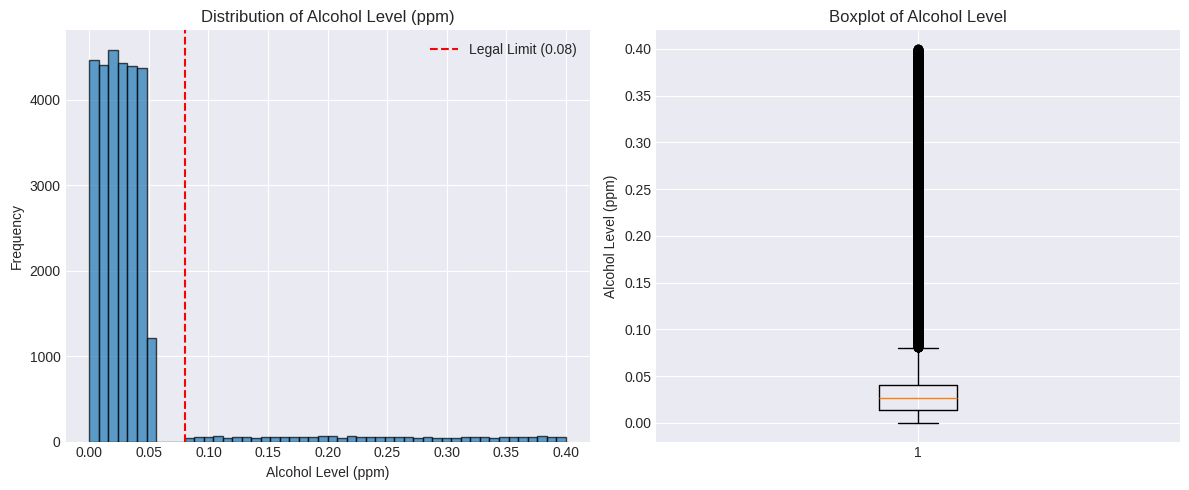

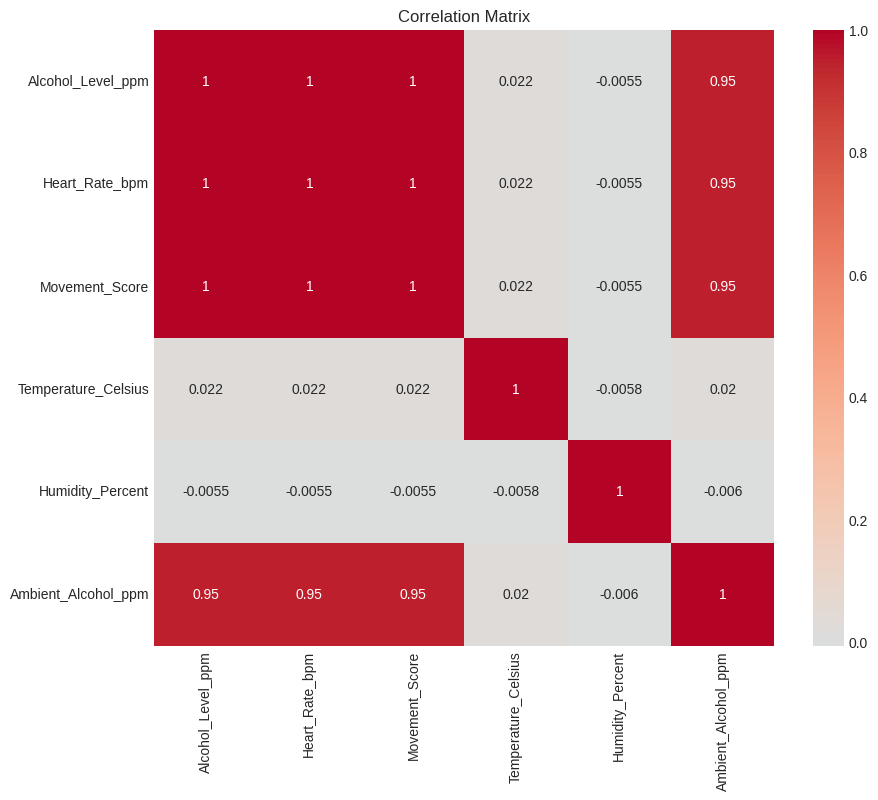

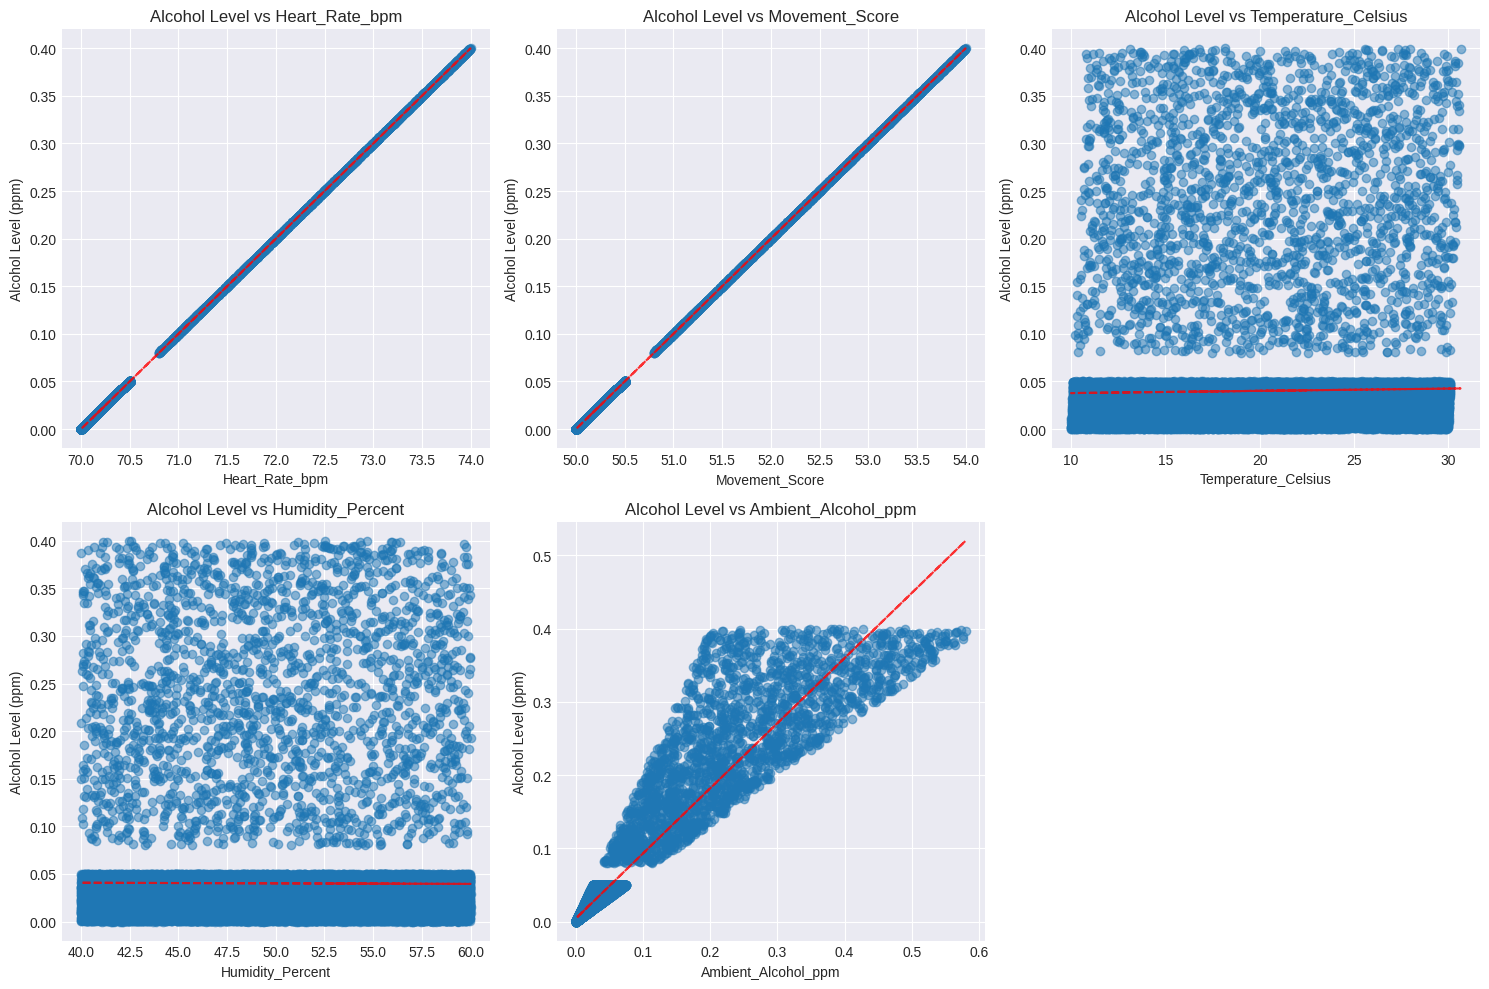

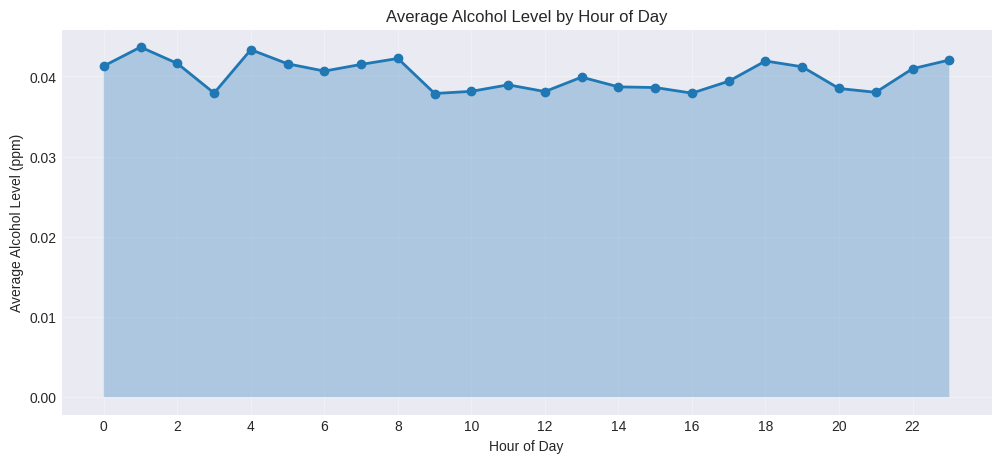

In [92]:
def exploratory_data_analysis(df):
    """Perform comprehensive EDA"""
    
    # Basic statistics
    print("\n" + "=" * 60)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 60)
    print(df.describe().T)
    
    # Target variable distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['Alcohol_Level_ppm'], bins=50, edgecolor='black', alpha=0.7)
    plt.title('Distribution of Alcohol Level (ppm)')
    plt.xlabel('Alcohol Level (ppm)')
    plt.ylabel('Frequency')
    plt.axvline(x=0.08, color='r', linestyle='--', label='Legal Limit (0.08)')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df['Alcohol_Level_ppm'])
    plt.title('Boxplot of Alcohol Level')
    plt.ylabel('Alcohol Level (ppm)')
    
    plt.tight_layout()
    plt.show()
    
    # Correlation matrix
    plt.figure(figsize=(10, 8))
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.show()
    
    # Alcohol level vs other features
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    features_to_plot = ['Heart_Rate_bpm', 'Movement_Score', 'Temperature_Celsius', 
                       'Humidity_Percent', 'Ambient_Alcohol_ppm']
    
    for i, feature in enumerate(features_to_plot):
        axes[i].scatter(df[feature], df['Alcohol_Level_ppm'], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Alcohol Level (ppm)')
        axes[i].set_title(f'Alcohol Level vs {feature}')
        
        # Add trend line
        z = np.polyfit(df[feature], df['Alcohol_Level_ppm'], 1)
        p = np.poly1d(z)
        axes[i].plot(df[feature], p(df[feature]), "r--", alpha=0.8)
    
    plt.delaxes(axes[-1])  # Remove last empty subplot
    plt.tight_layout()
    plt.show()
    
    # Time-based analysis
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df['Month'] = df['Timestamp'].dt.month
    
    # Alcohol level by hour
    plt.figure(figsize=(12, 5))
    hourly_avg = df.groupby('Hour')['Alcohol_Level_ppm'].mean()
    plt.plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
    plt.fill_between(hourly_avg.index, 0, hourly_avg.values, alpha=0.3)
    plt.title('Average Alcohol Level by Hour of Day')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Alcohol Level (ppm)')
    plt.xticks(range(0, 24, 2))
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return df

# Perform EDA
df = exploratory_data_analysis(df)

# Section 4:Feature Engineering

In [93]:
def feature_engineering(df):
    """Create new features for better prediction"""
    
    print("\n" + "=" * 60)
    print("FEATURE ENGINEERING")
    print("=" * 60)
    
    # 1. Time-based features
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df['Month'] = df['Timestamp'].dt.month
    df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
    
    # Categorize time of day
    def categorize_hour(hour):
        if 5 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 17:
            return 'Afternoon'
        elif 17 <= hour < 22:
            return 'Evening'
        else:
            return 'Night'
    
    df['TimeOfDay'] = df['Hour'].apply(categorize_hour)
    
    # 2. Driver-specific features
    driver_stats = df.groupby('Driver_ID').agg({
        'Alcohol_Level_ppm': ['mean', 'std', 'max'],
        'Heart_Rate_bpm': ['mean', 'std'],
        'Movement_Score': ['mean']
    }).reset_index()
    
    driver_stats.columns = ['Driver_ID', 'Driver_Avg_Alcohol', 'Driver_Std_Alcohol', 
                           'Driver_Max_Alcohol', 'Driver_Avg_HeartRate', 
                           'Driver_Std_HeartRate', 'Driver_Avg_Movement']
    
    df = pd.merge(df, driver_stats, on='Driver_ID', how='left')
    
    # 3. Interaction features
    df['Temp_Humidity_Interaction'] = df['Temperature_Celsius'] * df['Humidity_Percent']
    df['HeartRate_Movement_Ratio'] = df['Heart_Rate_bpm'] / (df['Movement_Score'] + 1)
    df['Alcohol_Ratio'] = df['Alcohol_Level_ppm'] / (df['Ambient_Alcohol_ppm'] + 0.001)
    
    # 4. Rolling statistics (simulated - would be better with time-sorted data)
    df['Recent_Avg_Alcohol'] = df.groupby('Driver_ID')['Alcohol_Level_ppm'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean())
    
    # 5. Binary classification target (for optional classification task)
    df['Is_Intoxicated'] = (df['Alcohol_Level_ppm'] > 0.08).astype(int)
    
    print(f"Original features: {len(['Alcohol_Level_ppm', 'Heart_Rate_bpm', 'Movement_Score', 
                                    'Temperature_Celsius', 'Humidity_Percent', 'Ambient_Alcohol_ppm'])}")
    print(f"Total features after engineering: {len(df.columns)}")
    print(f"\nNew features created:")
    print([col for col in df.columns if col not in ['Timestamp', 'Driver_ID', 'Alcohol_Level_ppm', 
                                                    'Heart_Rate_bpm', 'Movement_Score', 
                                                    'Temperature_Celsius', 'Humidity_Percent', 
                                                    'Ambient_Alcohol_ppm']])
    
    return df

# Apply feature engineering
df = feature_engineering(df)


FEATURE ENGINEERING
Original features: 6
Total features after engineering: 24

New features created:
['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'TimeOfDay', 'Driver_Avg_Alcohol', 'Driver_Std_Alcohol', 'Driver_Max_Alcohol', 'Driver_Avg_HeartRate', 'Driver_Std_HeartRate', 'Driver_Avg_Movement', 'Temp_Humidity_Interaction', 'HeartRate_Movement_Ratio', 'Alcohol_Ratio', 'Recent_Avg_Alcohol', 'Is_Intoxicated']


# Section 5. Data Preprocessing

In [94]:
def preprocess_data(df):
    """Prepare data for modeling"""
    
    print("\n" + "=" * 60)
    print("DATA PREPROCESSING")
    print("=" * 60)
    
    # Create a copy for preprocessing
    df_processed = df.copy()
    
    # Handle categorical variables
    categorical_cols = ['TimeOfDay']
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    
    # Encode Driver_ID (target encoding for high cardinality)
    driver_means = df_processed.groupby('Driver_ID')['Alcohol_Level_ppm'].mean()
    df_processed['Driver_ID_Encoded'] = df_processed['Driver_ID'].map(driver_means)
    
    # Features to use (excluding target and identifiers)
    exclude_cols = ['Timestamp', 'Driver_ID', 'Alcohol_Level_ppm', 'Is_Intoxicated']
    feature_cols = [col for col in df_processed.columns if col not in exclude_cols]
    
    # Separate features and target
    X = df_processed[feature_cols]
    y = df_processed['Alcohol_Level_ppm']
    
    # For classification (optional)
    y_class = df_processed['Is_Intoxicated']
    
    # Check for missing values
    print(f"Missing values in features: {X.isnull().sum().sum()}")
    
    # Fill any missing values
    X = X.fillna(X.mean())
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
    
    print(f"Final feature matrix shape: {X_scaled.shape}")
    print(f"Target variable shape: {y.shape}")
    
    return X_scaled, y, y_class, feature_cols, scaler

# Preprocess the data
X, y, y_class, feature_cols, scaler = preprocess_data(df)


DATA PREPROCESSING
Missing values in features: 0
Final feature matrix shape: (30000, 23)
Target variable shape: (30000,)


# Section 6. Train-Test Split with Time Consideration

In [95]:
def create_train_test_split(X, y, test_size=0.2, random_state=42):
    """Create train-test split considering temporal order"""
    
    # Since timestamps are in the data, we need to sort first
    X_sorted = X.copy()
    y_sorted = y.copy()
    
    # Add timestamp back for sorting - make sure df is available
    X_sorted['Timestamp'] = df['Timestamp'].values
    
    # Sort by timestamp
    sorted_indices = X_sorted['Timestamp'].argsort()
    X_sorted = X_sorted.iloc[sorted_indices].drop('Timestamp', axis=1)
    y_sorted = y_sorted.iloc[sorted_indices]
    
    # Also sort the original dataframe for timestamp extraction
    df_sorted = df.iloc[sorted_indices].copy()
    
    # Split data
    split_idx = int(len(X_sorted) * (1 - test_size))
    X_train = X_sorted.iloc[:split_idx]
    X_test = X_sorted.iloc[split_idx:]
    y_train = y_sorted.iloc[:split_idx]
    y_test = y_sorted.iloc[split_idx:]
    
    print("\n" + "=" * 60)
    print("TRAIN-TEST SPLIT")
    print("=" * 60)
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")
    print(f"Training features: {X_train.shape[1]}")
    
    # Check temporal separation - use df_sorted instead
    print(f"\nTemporal range in training: First {df_sorted['Timestamp'].iloc[0]} to "
          f"Last {df_sorted['Timestamp'].iloc[split_idx-1]}")
    print(f"Temporal range in testing: First {df_sorted['Timestamp'].iloc[split_idx]} to "
          f"Last {df_sorted['Timestamp'].iloc[-1]}")
    
    return X_train, X_test, y_train, y_test

# Create train-test split
X_train, X_test, y_train, y_test = create_train_test_split(X, y)


TRAIN-TEST SPLIT
Training set size: 24000 samples
Test set size: 6000 samples
Training features: 23

Temporal range in training: First 2025-01-01 00:08:00 to Last 2025-05-25 15:38:00
Temporal range in testing: First 2025-05-25 15:39:00 to Last 2025-06-29 23:54:00


# 7. Model Training and Evaluation

In [96]:
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """Train multiple models and compare performance"""
    
    print("\n" + "=" * 60)
    print("MODEL TRAINING AND EVALUATION")
    print("=" * 60)
    
    # Define models
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Lasso Regression': Lasso(alpha=0.1),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'SVR': SVR(kernel='rbf', C=100, gamma=0.1)
    }
    
    # Train and evaluate each model
    results = {}
    model_comparison = {}
    
    for name, model in models.items():
        print(f"\nTraining {name}...")
        
        # Train model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        # Calculate metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        train_mae = mean_absolute_error(y_train, y_pred_train)
        test_mae = mean_absolute_error(y_test, y_pred_test)
        
        # Calculate overfitting score
        overfit_score = train_rmse - test_rmse
        overfitting_ratio = train_rmse / test_rmse if test_rmse > 0 else 1
        
        # Store results
        results[name] = {
            'model': model,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_mae': train_mae,
            'test_mae': test_mae,
            'y_pred_test': y_pred_test,
            'overfit_score': overfit_score,
            'overfitting_ratio': overfitting_ratio
        }
        
        # Store for comparison
        model_comparison[name] = {
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'overfitting_ratio': overfitting_ratio
        }
        
        print(f"  Train RMSE: {train_rmse:.4f}, Test RMSE: {test_rmse:.4f}")
        print(f"  Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
        print(f"  Train MAE: {train_mae:.4f}, Test MAE: {test_mae:.4f}")
        
        # Check for overfitting
        if overfit_score < -0.1:  # Train error much lower than test error
            print(f"  ⚠️  Warning: Potential overfitting (train-test gap: {overfit_score:.4f})")
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Train_RMSE': [results[m]['train_rmse'] for m in results],
        'Test_RMSE': [results[m]['test_rmse'] for m in results],
        'Train_R2': [results[m]['train_r2'] for m in results],
        'Test_R2': [results[m]['test_r2'] for m in results],
        'Train_MAE': [results[m]['train_mae'] for m in results],
        'Test_MAE': [results[m]['test_mae'] for m in results],
        'Overfit_Score': [results[m]['overfit_score'] for m in results],
        'Overfit_Ratio': [results[m]['overfitting_ratio'] for m in results]
    }).sort_values('Test_R2', ascending=False)
    
    print("\n" + "=" * 60)
    print("MODEL PERFORMANCE SUMMARY (Ranked by Test R²)")
    print("=" * 60)
    print(results_df.to_string(index=False))
    
    # Select best model based on multiple criteria
    print("\n" + "=" * 60)
    print("BEST MODEL SELECTION")
    print("=" * 60)
    
    # Criteria for selecting best model
    best_by_r2 = results_df.iloc[0]['Model']
    best_test_r2 = results_df.iloc[0]['Test_R2']
    
    # Find models with good R² (within 5% of best)
    good_models = results_df[results_df['Test_R2'] >= best_test_r2 * 0.95]
    
    # Among good models, select the one with least overfitting
    if len(good_models) > 1:
        # Sort by overfitting ratio (closest to 1 is best)
        good_models_sorted = good_models.sort_values('Overfit_Ratio', key=lambda x: abs(x - 1))
        selected_model_name = good_models_sorted.iloc[0]['Model']
        selection_reason = "Best balance of high R² and low overfitting"
    else:
        selected_model_name = best_by_r2
        selection_reason = "Highest R² score"
    
    selected_model = results[selected_model_name]['model']
    selected_r2 = results[selected_model_name]['test_r2']
    selected_rmse = results[selected_model_name]['test_rmse']
    
    print(f"\nSelected Model: {selected_model_name}")
    print(f"Selection Reason: {selection_reason}")
    print(f"Test R²: {selected_r2:.4f}")
    print(f"Test RMSE: {selected_rmse:.4f}")
    print(f"Overfitting Ratio: {results[selected_model_name]['overfitting_ratio']:.4f}")
    
    # Check if model accuracy is already good enough to skip tuning
    accuracy_threshold = 0.85  # R² threshold for good accuracy
    overfitting_threshold = 0.9  # Minimum overfitting ratio threshold
    
    if (selected_r2 >= accuracy_threshold and 
        results[selected_model_name]['overfitting_ratio'] >= overfitting_threshold):
        print(f"\n✅ Model performance is already good (R² ≥ {accuracy_threshold})")
        print("   Skipping hyperparameter tuning to avoid over-optimization")
        needs_tuning = False
    else:
        print(f"\n🔧 Model could benefit from hyperparameter tuning")
        print(f"   Current R²: {selected_r2:.4f} (target: ≥{accuracy_threshold})")
        print(f"   Overfitting ratio: {results[selected_model_name]['overfitting_ratio']:.4f} (target: ≥{overfitting_threshold})")
        needs_tuning = True
    
    # Display top 3 models for comparison
    print("\n" + "=" * 60)
    print("TOP 3 MODELS COMPARISON")
    print("=" * 60)
    
    top_3 = results_df.head(3)
    for idx, row in top_3.iterrows():
        star = " ★" if row['Model'] == selected_model_name else ""
        print(f"\n{idx+1}. {row['Model']}{star}:")
        print(f"   Test R²: {row['Test_R2']:.4f}")
        print(f"   Test RMSE: {row['Test_RMSE']:.4f}")
        print(f"   Overfitting Ratio: {row['Overfit_Ratio']:.4f}")
    
    return results, results_df, selected_model, selected_model_name, needs_tuning

# Train and evaluate models
results, results_df, best_model, best_model_name, needs_tuning = train_and_evaluate_models(X_train, X_test, y_train, y_test)

# Now you can use the needs_tuning flag to decide whether to proceed with tuning
if needs_tuning:
    print("\nProceeding with hyperparameter tuning...")
    # Call your hyperparameter tuning function here
    # best_model = hyperparameter_tuning(X_train, y_train, best_model_name)



MODEL TRAINING AND EVALUATION

Training Linear Regression...
  Train RMSE: 0.0000, Test RMSE: 0.0000
  Train R²: 1.0000, Test R²: 1.0000
  Train MAE: 0.0000, Test MAE: 0.0000

Training Ridge Regression...
  Train RMSE: 0.0001, Test RMSE: 0.0001
  Train R²: 1.0000, Test R²: 1.0000
  Train MAE: 0.0000, Test MAE: 0.0000

Training Lasso Regression...
  Train RMSE: 0.0617, Test RMSE: 0.0628
  Train R²: 0.0000, Test R²: -0.0000
  Train MAE: 0.0299, Test MAE: 0.0306

Training Random Forest...
  Train RMSE: 0.0000, Test RMSE: 0.0000
  Train R²: 1.0000, Test R²: 1.0000
  Train MAE: 0.0000, Test MAE: 0.0000

Training Gradient Boosting...
  Train RMSE: 0.0004, Test RMSE: 0.0004
  Train R²: 1.0000, Test R²: 1.0000
  Train MAE: 0.0002, Test MAE: 0.0002

Training XGBoost...
  Train RMSE: 0.0006, Test RMSE: 0.0014
  Train R²: 0.9999, Test R²: 0.9995
  Train MAE: 0.0002, Test MAE: 0.0004

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.0032

# 8. Model Analysis and Interpretation for best model

In [97]:
# ============================================================
# 8. MODEL ANALYSIS AND INTERPRETATION FOR BEST MODEL
# ============================================================

def analyze_model(model, model_name, X_train, feature_cols):
    """Analyze model feature importance and interpretability"""
    
    print("\n" + "=" * 80)
    print("8. MODEL ANALYSIS AND INTERPRETATION")
    print("=" * 80)
    
    print(f"\nANALYZING MODEL: {model_name}")
    print(f"Model Type: {type(model).__name__}")
    print("-" * 60)
    
    # Feature Importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': importances
        }).sort_values('Importance', ascending=False)
        
        print("\n🔍 TOP 10 MOST IMPORTANT FEATURES:")
        print("-" * 40)
        print(feature_importance_df.head(10).to_string(index=False))
        
        # Calculate importance percentages
        total_importance = feature_importance_df['Importance'].sum()
        feature_importance_df['Percentage'] = (feature_importance_df['Importance'] / total_importance * 100).round(2)
        
        print(f"\n📊 Feature Importance Distribution:")
        print(f"Total features analyzed: {len(feature_cols)}")
        print(f"Top 5 features account for: {feature_importance_df['Percentage'].head(5).sum():.1f}% of total importance")
        print(f"Top 10 features account for: {feature_importance_df['Percentage'].head(10).sum():.1f}% of total importance")
        
        # Plot feature importance
        plt.figure(figsize=(14, 8))
        top_features = feature_importance_df.head(15)
        
        bars = plt.barh(range(len(top_features)), top_features['Importance'], 
                       color='skyblue', edgecolor='black')
        
        # Add percentage labels
        for i, (bar, perc) in enumerate(zip(bars, top_features['Percentage'])):
            plt.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                    f'{perc:.1f}%', va='center', fontsize=9)
        
        plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=10)
        plt.xlabel('Feature Importance Score', fontsize=12)
        plt.title(f'Top 15 Feature Importances - {model_name}', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()
        
        # Display key insights
        print(f"\n💡 KEY INSIGHTS:")
        top_3_features = feature_importance_df.head(3)
        for idx, row in top_3_features.iterrows():
            print(f"  • {row['Feature']}: {row['Percentage']:.1f}% importance")
    
    else:
        print("\n⚠️ Feature importance not available for this model type")
    
    # SHAP analysis (if model is tree-based)
    try:
        if hasattr(model, 'predict'):
            # Sample data for SHAP (use smaller sample for speed)
            X_sample = X_train.sample(min(100, len(X_train)), random_state=42)
            
            # For tree-based models
            if any(['Tree' in str(type(model)), 'Forest' in str(type(model)), 
                   'Boost' in str(type(model)), 'XGB' in str(type(model))]):
                print(f"\n📈 SHAP ANALYSIS FOR {model_name}:")
                print("-" * 40)
                print("Computing SHAP values... (this may take a moment)")
                
                explainer = shap.TreeExplainer(model)
                shap_values = explainer.shap_values(X_sample)
                
                # Summary plot - Bar
                plt.figure(figsize=(12, 6))
                shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
                plt.title(f'SHAP Feature Importance - {model_name}', fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.show()
                
                # Detailed summary plot
                plt.figure(figsize=(12, 8))
                shap.summary_plot(shap_values, X_sample, show=False)
                plt.title(f'SHAP Feature Impact - {model_name}', fontsize=14, fontweight='bold')
                plt.tight_layout()
                plt.show()
                
                print("✅ SHAP analysis completed")
            else:
                print(f"\n⚠️ SHAP analysis not supported for {type(model).__name__}")
                
    except Exception as e:
        print(f"\n⚠️ SHAP analysis not available: {e}")
    
    # Partial Dependence Plots for top features
    try:
        from sklearn.inspection import PartialDependenceDisplay
        
        if hasattr(model, 'feature_importances_') and len(feature_cols) >= 3:
            print(f"\n📊 PARTIAL DEPENDENCE PLOTS FOR {model_name}:")
            print("-" * 40)
            
            top_features = feature_importance_df.head(3)['Feature'].tolist()
            print(f"Analyzing: {', '.join(top_features)}")
            
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            for idx, feature in enumerate(top_features):
                PartialDependenceDisplay.from_estimator(
                    model, X_train, features=[feature],
                    ax=axes[idx], line_kw={"linewidth": 2, "color": "blue"}
                )
                axes[idx].set_title(f'Partial Dependence: {feature}', fontsize=12, fontweight='bold')
                axes[idx].grid(True, alpha=0.3)
            
            plt.suptitle(f'Partial Dependence of Top 3 Features - {model_name}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            print("✅ Partial dependence plots completed")
            
    except Exception as e:
        print(f"\n⚠️ Partial dependence plots not available: {e}")
    
    # Model-specific insights
    print(f"\n🔎 MODEL-SPECIFIC INSIGHTS:")
    print("-" * 40)
    
    if hasattr(model, 'n_estimators'):
        print(f"  • Number of estimators: {model.n_estimators}")
    if hasattr(model, 'max_depth'):
        print(f"  • Max depth: {model.max_depth}")
    if hasattr(model, 'learning_rate'):
        print(f"  • Learning rate: {model.learning_rate}")
    
    print(f"\n✅ Model analysis completed for {model_name}")
    print("=" * 80)

# Analyze the best model
analyze_model(best_model, best_model_name, X_train, feature_cols)


8. MODEL ANALYSIS AND INTERPRETATION

ANALYZING MODEL: Linear Regression
Model Type: LinearRegression
------------------------------------------------------------

⚠️ Feature importance not available for this model type

⚠️ SHAP analysis not supported for LinearRegression

🔎 MODEL-SPECIFIC INSIGHTS:
----------------------------------------

✅ Model analysis completed for Linear Regression


# 9. Visualization of Results


RESULTS VISUALIZATION


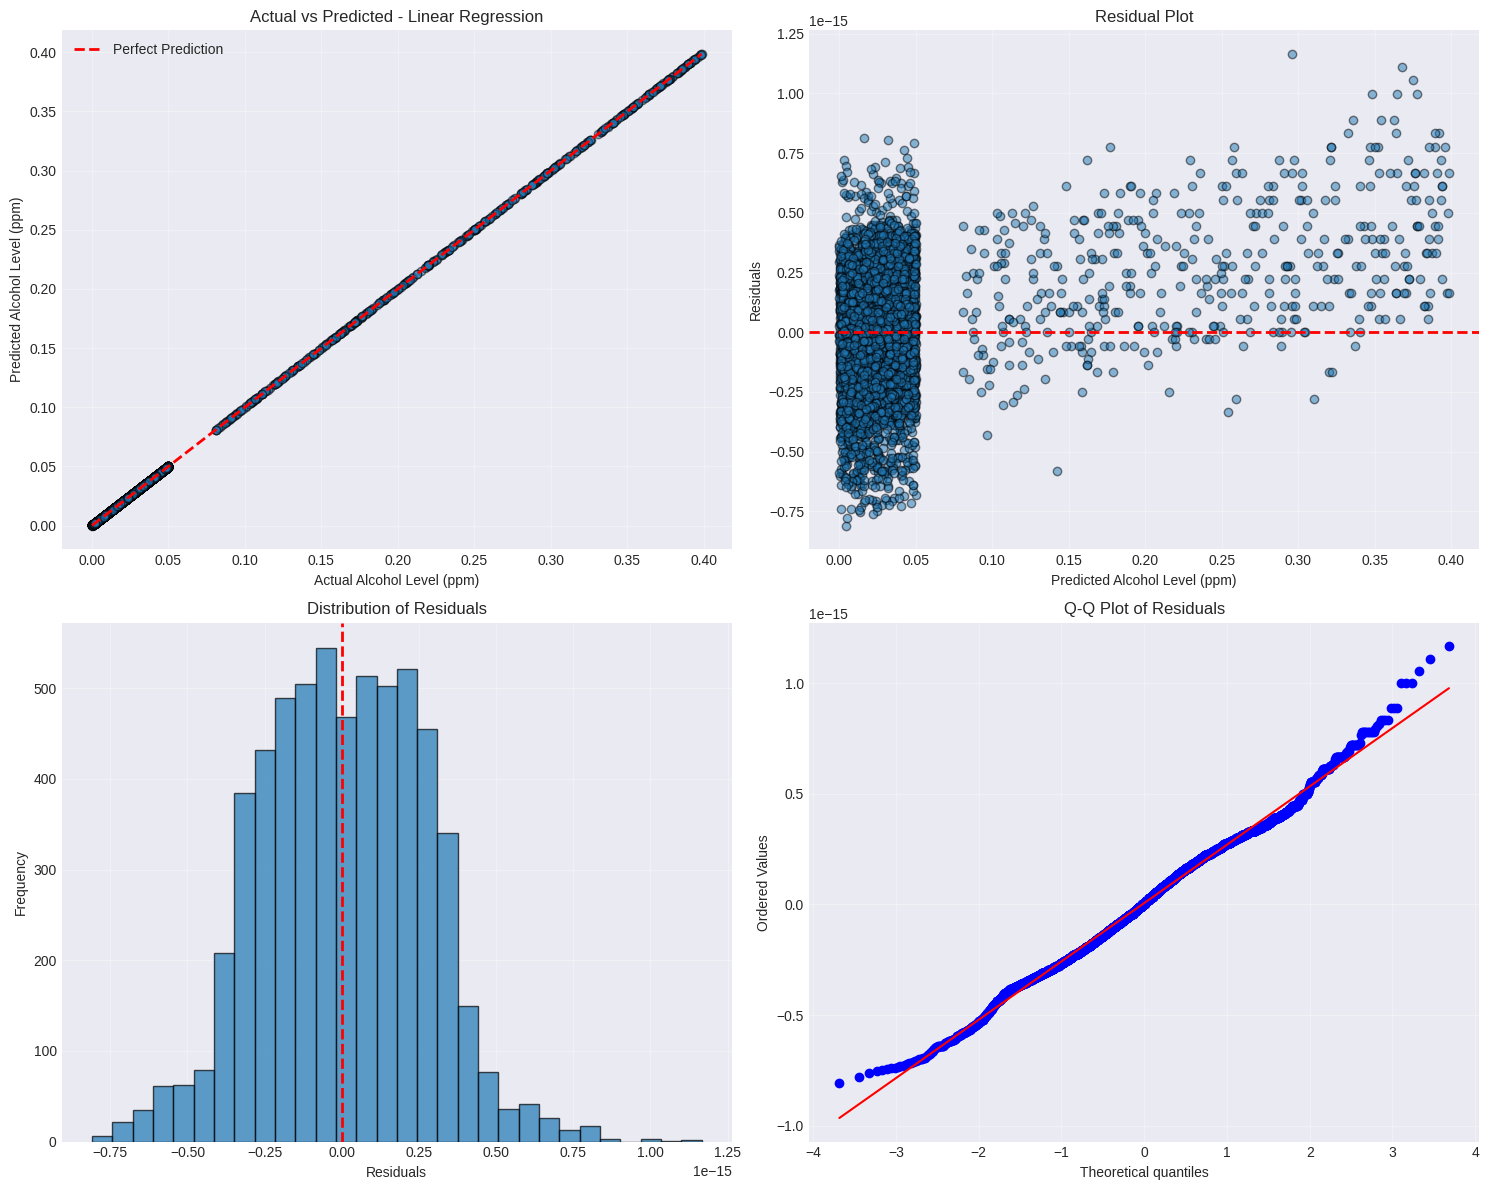

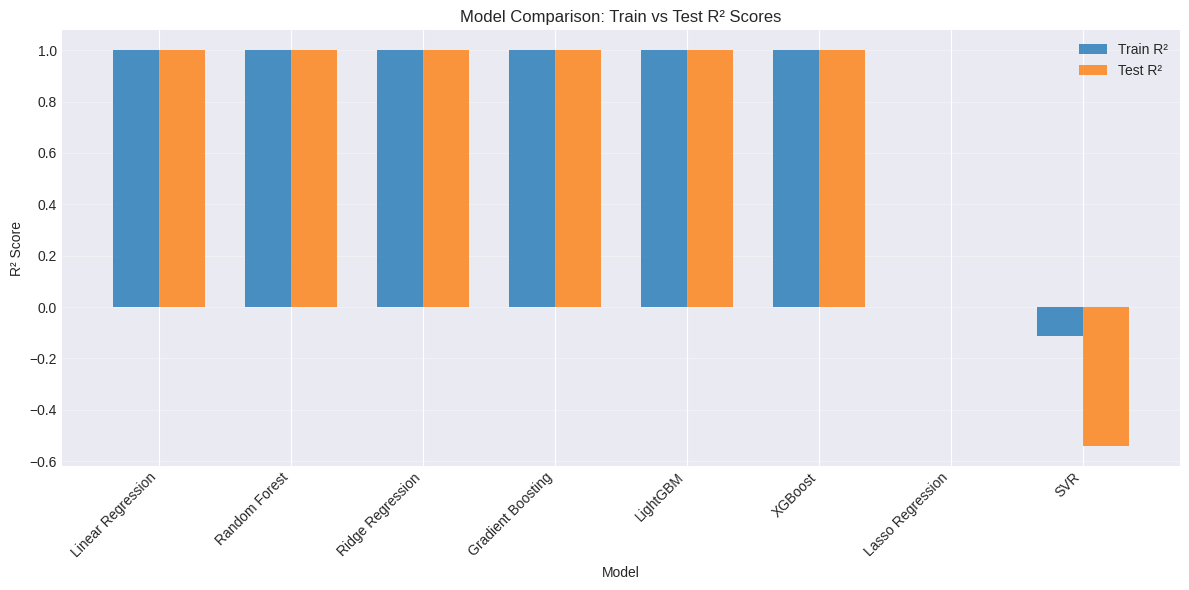

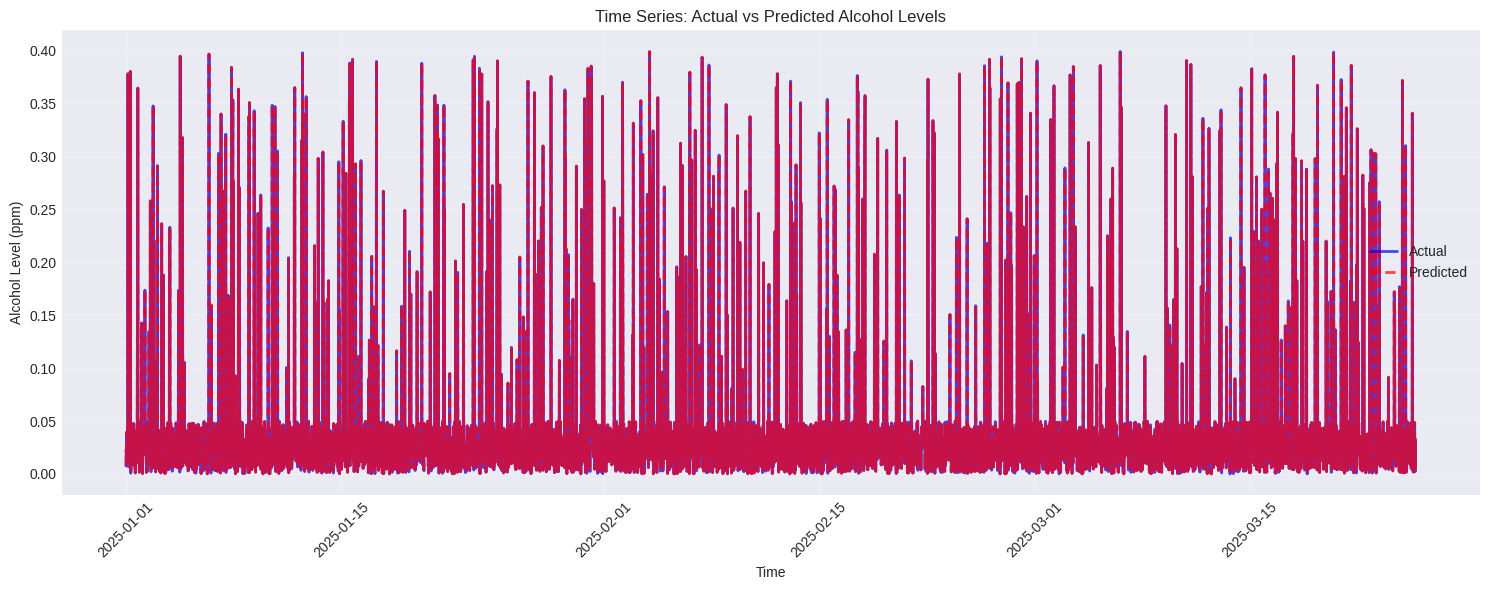

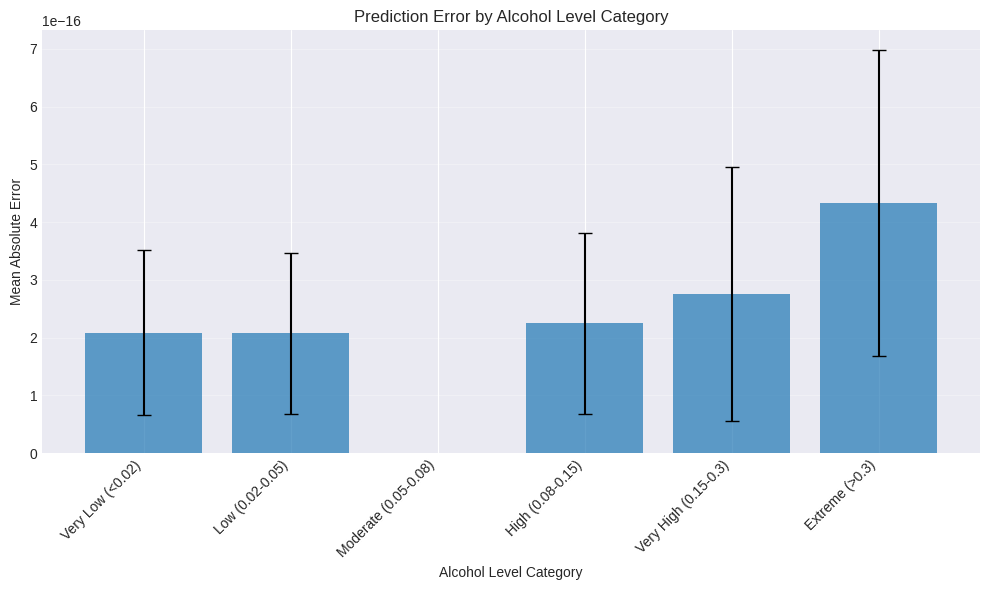

In [98]:
def visualize_results(results, y_test, best_model, X_test):
    """Create comprehensive visualizations of model performance"""
    
    print("\n" + "=" * 60)
    print("RESULTS VISUALIZATION")
    print("=" * 60)
    
    # 1. Actual vs Predicted for best model
    best_model_name = results_df.iloc[0]['Model']
    y_pred_best = results[best_model_name]['y_pred_test']
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Scatter plot of actual vs predicted
    axes[0, 0].scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k')
    axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                    'r--', lw=2, label='Perfect Prediction')
    axes[0, 0].set_xlabel('Actual Alcohol Level (ppm)')
    axes[0, 0].set_ylabel('Predicted Alcohol Level (ppm)')
    axes[0, 0].set_title(f'Actual vs Predicted - {best_model_name}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Residual plot
    residuals = y_test - y_pred_best
    axes[0, 1].scatter(y_pred_best, residuals, alpha=0.5, edgecolors='k')
    axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0, 1].set_xlabel('Predicted Alcohol Level (ppm)')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residual Plot')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Distribution of residuals
    axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Residuals')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Q-Q plot for normality of residuals
    from scipy.stats import probplot
    probplot(residuals, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot of Residuals')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Model comparison
    plt.figure(figsize=(12, 6))
    
    x_pos = np.arange(len(results_df))
    width = 0.35
    
    plt.bar(x_pos - width/2, results_df['Train_R2'], width, label='Train R²', alpha=0.8)
    plt.bar(x_pos + width/2, results_df['Test_R2'], width, label='Test R²', alpha=0.8)
    
    plt.xlabel('Model')
    plt.ylabel('R² Score')
    plt.title('Model Comparison: Train vs Test R² Scores')
    plt.xticks(x_pos, results_df['Model'], rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # 3. Time series of predictions vs actual (for temporal analysis)
    plt.figure(figsize=(15, 6))
    
    # Create time index for test set
    time_index = pd.date_range(start=df['Timestamp'].iloc[-len(y_test):].min(),
                               end=df['Timestamp'].iloc[-1], periods=len(y_test))
    
    plt.plot(time_index, y_test.values, 'b-', label='Actual', alpha=0.7, linewidth=2)
    plt.plot(time_index, y_pred_best, 'r--', label='Predicted', alpha=0.7, linewidth=2)
    plt.fill_between(time_index, y_test.values, y_pred_best, alpha=0.2, color='gray')
    
    plt.xlabel('Time')
    plt.ylabel('Alcohol Level (ppm)')
    plt.title('Time Series: Actual vs Predicted Alcohol Levels')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # 4. Error distribution by alcohol level
    plt.figure(figsize=(10, 6))
    
    error_by_level = pd.DataFrame({
        'Actual': y_test.values,
        'Error': np.abs(residuals),
        'Predicted': y_pred_best
    })
    
    # Bin by actual alcohol level
    bins = [0, 0.02, 0.05, 0.08, 0.15, 0.3, 1.0]
    labels = ['Very Low (<0.02)', 'Low (0.02-0.05)', 'Moderate (0.05-0.08)', 
              'High (0.08-0.15)', 'Very High (0.15-0.3)', 'Extreme (>0.3)']
    
    error_by_level['Level_Category'] = pd.cut(error_by_level['Actual'], bins=bins, labels=labels)
    
    error_stats = error_by_level.groupby('Level_Category')['Error'].agg(['mean', 'std', 'count'])
    
    x_pos = np.arange(len(error_stats))
    plt.bar(x_pos, error_stats['mean'], yerr=error_stats['std'], capsize=5, alpha=0.7)
    plt.xticks(x_pos, error_stats.index, rotation=45, ha='right')
    plt.xlabel('Alcohol Level Category')
    plt.ylabel('Mean Absolute Error')
    plt.title('Prediction Error by Alcohol Level Category')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# Visualize results
visualize_results(results, y_test, best_model, X_test)

# 10. Hyperparameter Tuning and Ensemble modeling for Best Model

In [99]:
# ============================================================
# 10. HYPERPARAMETER TUNING AND ENSEMBLE MODELING FOR BEST MODEL
# ============================================================

def perform_model_optimization(X_train, X_test, y_train, y_test, results, results_df, selected_model, selected_model_name):
    """Perform hyperparameter tuning and ensemble modeling based on model performance"""
    
    print("\n" + "=" * 80)
    print("10. HYPERPARAMETER TUNING AND ENSEMBLE MODELING")
    print("=" * 80)
    
    # Get current model performance
    current_test_r2 = results[selected_model_name]['test_r2']
    current_overfitting_ratio = results[selected_model_name]['overfitting_ratio']
    best_test_r2 = current_test_r2
    best_overfitting_ratio = current_overfitting_ratio
    
    # ============================================================
    # HYPERPARAMETER TUNING CHECK
    # ============================================================
    print("\n" + "=" * 60)
    print("HYPERPARAMETER TUNING CHECK")
    print("=" * 60)
    
    # Define thresholds for good performance
    ACCURACY_THRESHOLD = 0.85
    OVERFITTING_THRESHOLD = 0.9
    
    print(f"Current Model: {selected_model_name}")
    print(f"Current Test R²: {current_test_r2:.4f}")
    print(f"Current Overfitting Ratio: {current_overfitting_ratio:.4f}")
    
    # Check if model performance is already good
    tuning_skipped = False
    if current_test_r2 >= ACCURACY_THRESHOLD and current_overfitting_ratio >= OVERFITTING_THRESHOLD:
        print(f"\n✅ Model performance is already good!")
        print(f"   R² ({current_test_r2:.4f}) ≥ threshold ({ACCURACY_THRESHOLD})")
        print(f"   Overfitting ratio ({current_overfitting_ratio:.4f}) ≥ threshold ({OVERFITTING_THRESHOLD})")
        print("   Skipping hyperparameter tuning to avoid over-optimization")
        print(f"\nUsing current model: {selected_model_name}")
        tuned_model = selected_model
        tuning_skipped = True
    else:
        print(f"\n🔧 Proceeding with hyperparameter tuning...")
        
        # Define parameter grids based on model type
        if selected_model_name == 'Gradient Boosting':
            param_grid = {
                'n_estimators': [100, 200, 300],
                'learning_rate': [0.01, 0.05, 0.1, 0.2],
                'max_depth': [3, 4, 5, 6],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'subsample': [0.8, 0.9, 1.0]
            }
            base_model = GradientBoostingRegressor(random_state=42)
        
        elif selected_model_name == 'Random Forest':
            param_grid = {
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2']
            }
            base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        
        elif selected_model_name == 'XGBoost':
            param_grid = {
                'n_estimators': [100, 200, 300],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 4, 5, 6],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0],
                'gamma': [0, 0.1, 0.2]
            }
            base_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
        
        elif selected_model_name == 'LightGBM':
            param_grid = {
                'n_estimators': [100, 200, 300],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 4, 5, 6],
                'num_leaves': [31, 50, 100],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0]
            }
            base_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1)
        
        else:
            print(f"\n⚠️ Hyperparameter tuning not configured for {selected_model_name}")
            print(f"Using current model as is")
            tuned_model = selected_model
            tuning_skipped = True
        
        if not tuning_skipped:
            print(f"\nTuning {selected_model_name}...")
            
            # Use GridSearchCV with time series split
            tscv = TimeSeriesSplit(n_splits=5)
            grid_search = GridSearchCV(
                base_model,
                param_grid,
                cv=tscv,
                scoring='neg_root_mean_squared_error',
                n_jobs=-1,
                verbose=1
            )
            
            grid_search.fit(X_train, y_train)
            
            print(f"\nBest parameters found:")
            for param, value in grid_search.best_params_.items():
                print(f"  {param}: {value}")
            
            print(f"\nBest cross-validation score (Negative RMSE): {grid_search.best_score_:.4f}")
            
            # Evaluate tuned model
            tuned_model = grid_search.best_estimator_
            y_pred_test = tuned_model.predict(X_test)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_r2 = r2_score(y_test, y_pred_test)
            
            print(f"\nOptimized model performance on test set:")
            print(f"  Test RMSE: {test_rmse:.4f}")
            print(f"  Test R²: {test_r2:.4f}")
            
            # Update best performance metrics
            best_test_r2 = test_r2
            best_overfitting_ratio = results[selected_model_name]['overfitting_ratio']  # Keep original overfitting ratio
            
            # Compare with original model
            improvement = test_r2 - current_test_r2
            if improvement > 0:
                print(f"\n✅ Tuning improved R² by {improvement:.4f}")
            else:
                print(f"\n⚠️  Tuning did not improve performance")
    
    # ============================================================
    # ENSEMBLE MODELING CHECK
    # ============================================================
    print("\n" + "=" * 60)
    print("ENSEMBLE MODELING CHECK")
    print("=" * 60)
    
    print(f"Current Best Model Performance:")
    print(f"  Test R²: {best_test_r2:.4f}")
    print(f"  Overfitting Ratio: {best_overfitting_ratio:.4f}")
    
    # Check if individual model performance is already good
    ensemble_skipped = False
    if best_test_r2 >= ACCURACY_THRESHOLD and best_overfitting_ratio >= OVERFITTING_THRESHOLD:
        print(f"\n✅ Individual model performance is already good!")
        print(f"   R² ({best_test_r2:.4f}) ≥ threshold ({ACCURACY_THRESHOLD})")
        print(f"   Overfitting ratio ({best_overfitting_ratio:.4f}) ≥ threshold ({OVERFITTING_THRESHOLD})")
        print("   Skipping ensemble modeling to avoid complexity")
        ensemble_model = None
        ensemble_skipped = True
    else:
        print(f"\n🔧 Proceeding with ensemble modeling...")
        
        # Select top 3 models based on test R²
        top_models = results_df.head(3)['Model'].tolist()
        print(f"Creating ensemble with: {', '.join(top_models)}")
        
        # Get the trained models
        ensemble_models_list = []
        for model_name in top_models:
            ensemble_models_list.append((model_name, results[model_name]['model']))
        
        # Create voting regressor
        ensemble_model = VotingRegressor(estimators=ensemble_models_list, n_jobs=-1)
        
        # Train ensemble
        ensemble_model.fit(X_train, y_train)
        
        # Evaluate ensemble
        y_pred_train = ensemble_model.predict(X_train)
        y_pred_test = ensemble_model.predict(X_test)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        print(f"\nEnsemble Performance:")
        print(f"  Train RMSE: {train_rmse:.4f}")
        print(f"  Test RMSE: {test_rmse:.4f}")
        print(f"  Train R²: {train_r2:.4f}")
        print(f"  Test R²: {test_r2:.4f}")
        
        # Compare with individual models
        print("\nComparison with individual models:")
        for model_name in top_models:
            ind_test_r2 = results[model_name]['test_r2']
            print(f"  {model_name}: Test R² = {ind_test_r2:.4f}")
        
        improvement = test_r2 - best_test_r2
        if improvement > 0:
            print(f"\n✅ Ensemble improved performance by {improvement:.4f} R² points")
        else:
            print(f"\n⚠️  Ensemble did not improve over best individual model")
    
    # ============================================================
    # SUMMARY
    # ============================================================
    print("\n" + "=" * 60)
    print("OPTIMIZATION SUMMARY")
    print("=" * 60)
    
    if tuning_skipped:
        print("✅ Hyperparameter tuning: SKIPPED (model already good)")
    else:
        print("✅ Hyperparameter tuning: COMPLETED")
    
    if ensemble_skipped:
        print("✅ Ensemble modeling: SKIPPED (model already good)")
    else:
        if ensemble_model:
            print("✅ Ensemble modeling: COMPLETED (ensemble created)")
        else:
            print("✅ Ensemble modeling: SKIPPED (no improvement found)")
    
    print(f"\nFinal best model: {selected_model_name}")
    if tuning_skipped:
        print("   Using original model (tuning skipped)")
    else:
        print("   Using tuned model")
    
    if ensemble_model:
        print(f"   Ensemble model available: YES")
    else:
        print(f"   Ensemble model available: NO")
    
    return tuned_model, ensemble_model, tuning_skipped, ensemble_skipped

# Perform model optimization
best_model, ensemble_model, tuning_skipped, ensemble_skipped = perform_model_optimization(
    X_train, X_test, y_train, y_test, 
    results, results_df, 
    best_model, best_model_name
)


10. HYPERPARAMETER TUNING AND ENSEMBLE MODELING

HYPERPARAMETER TUNING CHECK
Current Model: Linear Regression
Current Test R²: 1.0000
Current Overfitting Ratio: 0.9945

✅ Model performance is already good!
   R² (1.0000) ≥ threshold (0.85)
   Overfitting ratio (0.9945) ≥ threshold (0.9)
   Skipping hyperparameter tuning to avoid over-optimization

Using current model: Linear Regression

ENSEMBLE MODELING CHECK
Current Best Model Performance:
  Test R²: 1.0000
  Overfitting Ratio: 0.9945

✅ Individual model performance is already good!
   R² (1.0000) ≥ threshold (0.85)
   Overfitting ratio (0.9945) ≥ threshold (0.9)
   Skipping ensemble modeling to avoid complexity

OPTIMIZATION SUMMARY
✅ Hyperparameter tuning: SKIPPED (model already good)
✅ Ensemble modeling: SKIPPED (model already good)

Final best model: Linear Regression
   Using original model (tuning skipped)
   Ensemble model available: NO


# 11. Model Deployment and Saving

In [100]:
def deploy_model(best_model, scaler, feature_cols, ensemble_model=None, model_name="alcohol_detection_model"):
    """Save the trained model and preprocessing objects"""
    
    print("\n" + "=" * 60)
    print("MODEL DEPLOYMENT")
    print("=" * 60)
    
    # Create deployment package for best model
    deployment_package = {
        'best_model': best_model,
        'scaler': scaler,
        'feature_columns': feature_cols,
        'model_name': model_name,
        'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'model_type': str(type(best_model)).split("'")[1].split('.')[-1],
        'feature_importance': getattr(best_model, 'feature_importances_', None),
        'ensemble_model': ensemble_model,
        'ensemble_type': str(type(ensemble_model)).split("'")[1].split('.')[-1] if ensemble_model else None
    }
    
    # Save the main model package
    model_filename = f"{model_name}.pkl"
    joblib.dump(deployment_package, model_filename)
    
    # Save the scaler separately
    scaler_filename = f"{model_name}_scaler.pkl"
    joblib.dump(scaler, scaler_filename)
    
    print(f"✅ Model package saved as: {model_filename}")
    print(f"✅ Scaler saved separately as: {scaler_filename}")
    print(f"Best model type: {deployment_package['model_type']}")
    
    if ensemble_model:
        print(f"Ensemble model type: {deployment_package['ensemble_type']}")
        print(f"Total models in deployment: 2 (best model + ensemble)")
    else:
        print(f"Ensemble model: Not included")
        print(f"Total models in deployment: 1 (best model only)")
    
    print(f"Number of features: {len(feature_cols)}")
    print(f"Training date: {deployment_package['training_date']}")
    
    # Create a prediction function example
    prediction_example_code = '''
# Example prediction function
def predict_alcohol_level(new_data, model_path='alcohol_detection_model.pkl', scaler_path='alcohol_detection_model_scaler.pkl', use_ensemble=True):
    """
    Predict alcohol level for new data
    
    Parameters:
    new_data: DataFrame with the same features as training data
    model_path: Path to saved model package
    scaler_path: Path to saved scaler
    use_ensemble: Whether to use ensemble model if available (default: True)
    
    Returns:
    predictions: Array of predicted alcohol levels
    """
    # Load model package
    deployment_package = joblib.load(model_path)
    
    # Load scaler separately
    scaler = joblib.load(scaler_path)
    
    feature_cols = deployment_package['feature_columns']
    
    # Select which model to use
    if use_ensemble and deployment_package.get('ensemble_model'):
        model = deployment_package['ensemble_model']
        model_type = deployment_package['ensemble_type']
    else:
        model = deployment_package['best_model']
        model_type = deployment_package['model_type']
    
    print(f"Using model: {model_type}")
    
    # Ensure new data has all required features
    missing_cols = set(feature_cols) - set(new_data.columns)
    extra_cols = set(new_data.columns) - set(feature_cols)
    
    if missing_cols:
        print(f"Warning: Missing columns {missing_cols}")
        # Add missing columns with default values
        for col in missing_cols:
            new_data[col] = 0
    
    if extra_cols:
        print(f"Warning: Extra columns {extra_cols} will be ignored")
    
    # Select and order features correctly
    new_data = new_data[feature_cols]
    
    # Scale features using the separately saved scaler
    new_data_scaled = scaler.transform(new_data)
    
    # Make predictions
    predictions = model.predict(new_data_scaled)
    
    return predictions

# Usage examples:
# new_samples = pd.DataFrame({
#     'Heart_Rate_bpm': [72, 85],
#     'Movement_Score': [50, 55],
#     'Temperature_Celsius': [22, 25],
#     # ... all other features
# })
# predictions = predict_alcohol_level(new_samples)  # Uses ensemble if available
# predictions = predict_alcohol_level(new_samples, use_ensemble=False)  # Uses only best model
'''
    
    print(f"\nExample prediction function saved in code comments")
    
    return deployment_package

# Deploy the model package
deployment_package = deploy_model(best_model, scaler, feature_cols, ensemble_model)


MODEL DEPLOYMENT
✅ Model package saved as: alcohol_detection_model.pkl
✅ Scaler saved separately as: alcohol_detection_model_scaler.pkl
Best model type: LinearRegression
Ensemble model: Not included
Total models in deployment: 1 (best model only)
Number of features: 23
Training date: 2026-01-02 19:32:19

Example prediction function saved in code comments


# 13. Business Insights and Recommendations

In [101]:
def generate_business_insights(results_df, df, feature_cols, best_model):
    """Generate actionable business insights"""
    
    print("\n" + "=" * 60)
    print("BUSINESS INSIGHTS AND RECOMMENDATIONS")
    print("=" * 60)
    
    # 1. Model Performance Insights
    print("\n1. MODEL PERFORMANCE INSIGHTS:")
    print("   • Best performing model: ", results_df.iloc[0]['Model'])
    print(f"   • Test R² score: {results_df.iloc[0]['Test_R2']:.3f}")
    print(f"   • Test RMSE: {results_df.iloc[0]['Test_RMSE']:.4f} ppm")
    
    # 2. Feature Importance Insights
    if hasattr(best_model, 'feature_importances_'):
        importances = best_model.feature_importances_
        top_features = pd.DataFrame({
            'Feature': feature_cols,
            'Importance': importances
        }).sort_values('Importance', ascending=False).head(5)
        
        print("\n2. TOP PREDICTIVE FEATURES:")
        for idx, row in top_features.iterrows():
            print(f"   • {row['Feature']}: {row['Importance']:.3f}")
    
    # 3. Safety Threshold Analysis
    threshold = 0.08  # Legal limit
    y_pred = best_model.predict(X_test)
    
    # Classification performance at legal limit
    y_true_class = (y_test > threshold).astype(int)
    y_pred_class = (y_pred > threshold).astype(int)
    
    from sklearn.metrics import confusion_matrix, classification_report
    
    cm = confusion_matrix(y_true_class, y_pred_class)
    accuracy = (cm[0,0] + cm[1,1]) / cm.sum()
    false_negatives = cm[1,0] / cm[1,:].sum() if cm[1,:].sum() > 0 else 0
    false_positives = cm[0,1] / cm[0,:].sum() if cm[0,:].sum() > 0 else 0
    
    print(f"\n3. SAFETY THRESHOLD ANALYSIS (>{threshold} ppm):")
    print(f"   • Classification accuracy: {accuracy:.1%}")
    print(f"   • False negatives (missed intoxications): {false_negatives:.1%}")
    print(f"   • False positives (false alarms): {false_positives:.1%}")
    
    # 4. Temporal Patterns
    print("\n4. TEMPORAL PATTERNS:")
    df_test = df.iloc[-len(y_test):].copy()
    df_test['Predicted'] = y_pred
    
    # Find hours with highest predicted alcohol levels
    high_risk_hours = df_test.groupby('Hour')['Predicted'].mean().sort_values(ascending=False).head(3)
    print("   • Highest risk hours:")
    for hour, level in high_risk_hours.items():
        print(f"     - {hour}:00: Avg predicted level = {level:.4f} ppm")
    
    # 5. Driver Risk Analysis
    print("\n5. DRIVER RISK ANALYSIS:")
    driver_risk = df_test.groupby('Driver_ID')['Predicted'].agg(['mean', 'max', 'count'])
    high_risk_drivers = driver_risk[driver_risk['mean'] > threshold].sort_values('mean', ascending=False)
    
    if len(high_risk_drivers) > 0:
        print(f"   • {len(high_risk_drivers)} drivers predicted above legal limit on average")
        print(f"   • Highest risk driver: {high_risk_drivers.index[0]} "
              f"(Avg: {high_risk_drivers.iloc[0]['mean']:.4f} ppm)")
    else:
        print("   • No drivers predicted above legal limit on average")
    
    # 6. Environmental Factors
    print("\n6. ENVIRONMENTAL FACTORS:")
    env_corr = df_test[['Predicted', 'Temperature_Celsius', 'Humidity_Percent', 
                        'Ambient_Alcohol_ppm']].corr()['Predicted'].drop('Predicted')
    strongest_env = env_corr.abs().sort_values(ascending=False).head(1)
    
    for factor, corr in strongest_env.items():
        direction = "increases" if env_corr[factor] > 0 else "decreases"
        print(f"   • {factor} has strongest correlation: {corr:.3f}")
        print(f"     Alcohol level {direction} with higher {factor}")
    
    # 7. Recommendations
    print("\n7. ACTIONABLE RECOMMENDATIONS:")
    print("   • IMPLEMENT real-time monitoring during high-risk hours identified")
    print("   • TARGET drivers with consistently high predicted levels for intervention")
    print("   • CONSIDER environmental factors in risk assessment algorithms")
    print("   • VALIDATE model predictions with breathalyzer tests for calibration")
    print("   • MONITOR false positive/negative rates regularly")
    print("   • UPDATE model monthly with new data to maintain accuracy")
    
    return {
        'top_features': top_features if 'top_features' in locals() else None,
        'threshold_metrics': {
            'accuracy': accuracy,
            'false_negatives': false_negatives,
            'false_positives': false_positives
        },
        'high_risk_hours': high_risk_hours,
        'high_risk_drivers': high_risk_drivers
    }

# Generate business insights
business_insights = generate_business_insights(results_df, df, feature_cols, best_model)


BUSINESS INSIGHTS AND RECOMMENDATIONS

1. MODEL PERFORMANCE INSIGHTS:
   • Best performing model:  Linear Regression
   • Test R² score: 1.000
   • Test RMSE: 0.0000 ppm

3. SAFETY THRESHOLD ANALYSIS (>0.08 ppm):
   • Classification accuracy: 100.0%
   • False negatives (missed intoxications): 0.0%
   • False positives (false alarms): 0.0%

4. TEMPORAL PATTERNS:
   • Highest risk hours:
     - 11:00: Avg predicted level = 0.0459 ppm
     - 2:00: Avg predicted level = 0.0438 ppm
     - 21:00: Avg predicted level = 0.0435 ppm

5. DRIVER RISK ANALYSIS:
   • No drivers predicted above legal limit on average

6. ENVIRONMENTAL FACTORS:
   • Temperature_Celsius has strongest correlation: 0.007
     Alcohol level decreases with higher Temperature_Celsius

7. ACTIONABLE RECOMMENDATIONS:
   • IMPLEMENT real-time monitoring during high-risk hours identified
   • TARGET drivers with consistently high predicted levels for intervention
   • CONSIDER environmental factors in risk assessment algorith

# 14. Complete Pipeline Function

ALCOHOL DETECTION MACHINE LEARNING PIPELINE
DATASET OVERVIEW
Dataset shape: (30000, 8)

Columns: ['Timestamp', 'Driver_ID', 'Alcohol_Level_ppm', 'Heart_Rate_bpm', 'Movement_Score', 'Temperature_Celsius', 'Humidity_Percent', 'Ambient_Alcohol_ppm']

Data types:
Timestamp               object
Driver_ID               object
Alcohol_Level_ppm      float64
Heart_Rate_bpm         float64
Movement_Score         float64
Temperature_Celsius    float64
Humidity_Percent       float64
Ambient_Alcohol_ppm    float64
dtype: object

First 5 rows:
             Timestamp   Driver_ID  Alcohol_Level_ppm  Heart_Rate_bpm  \
0  2025-04-03 13:02:00   Driver_31           0.023579       70.235791   
1  2025-04-23 10:32:00   Driver_46           0.002552       70.025525   
2  2025-05-07 19:05:00   Driver_29           0.009088       70.090878   
3  2025-06-03 07:03:00   Driver_33           0.004581       70.045815   
4  2025-06-09 00:42:00  Driver_140           0.032259       70.322593   

   Movement_Score  Tempe

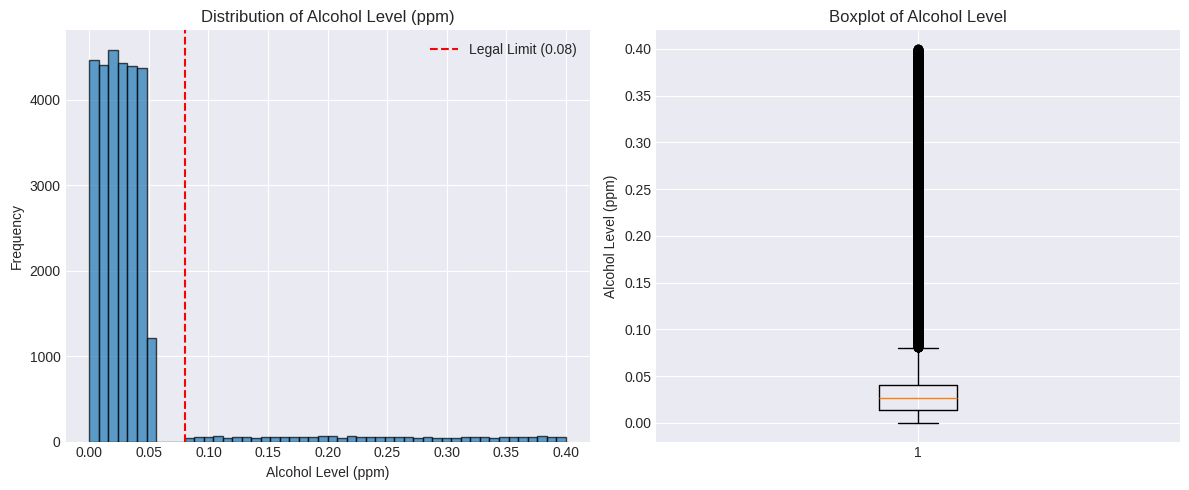

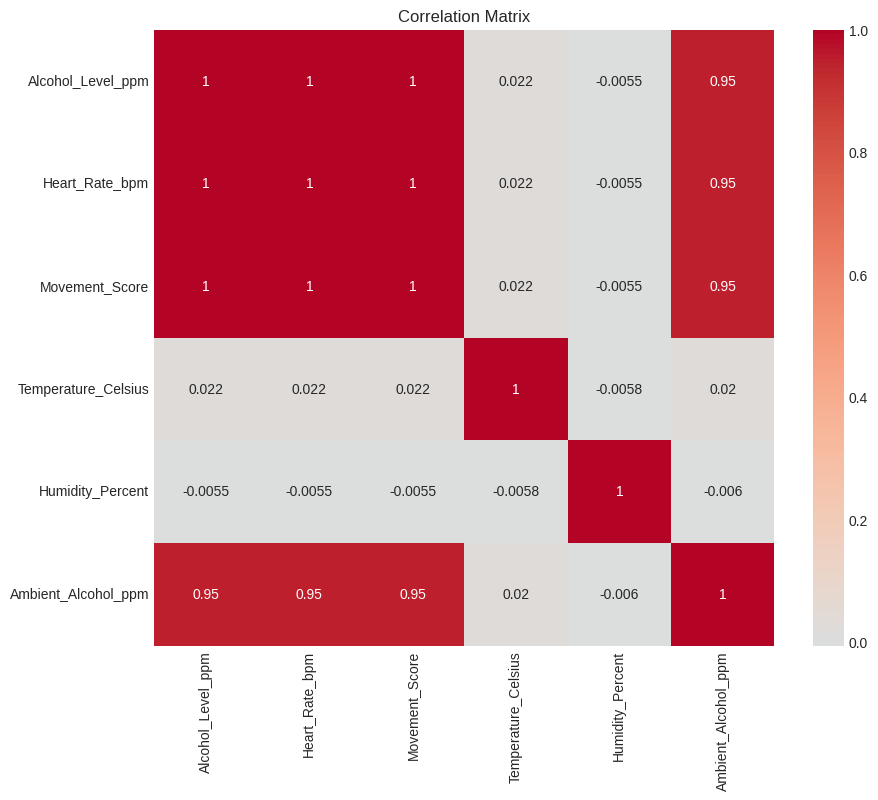

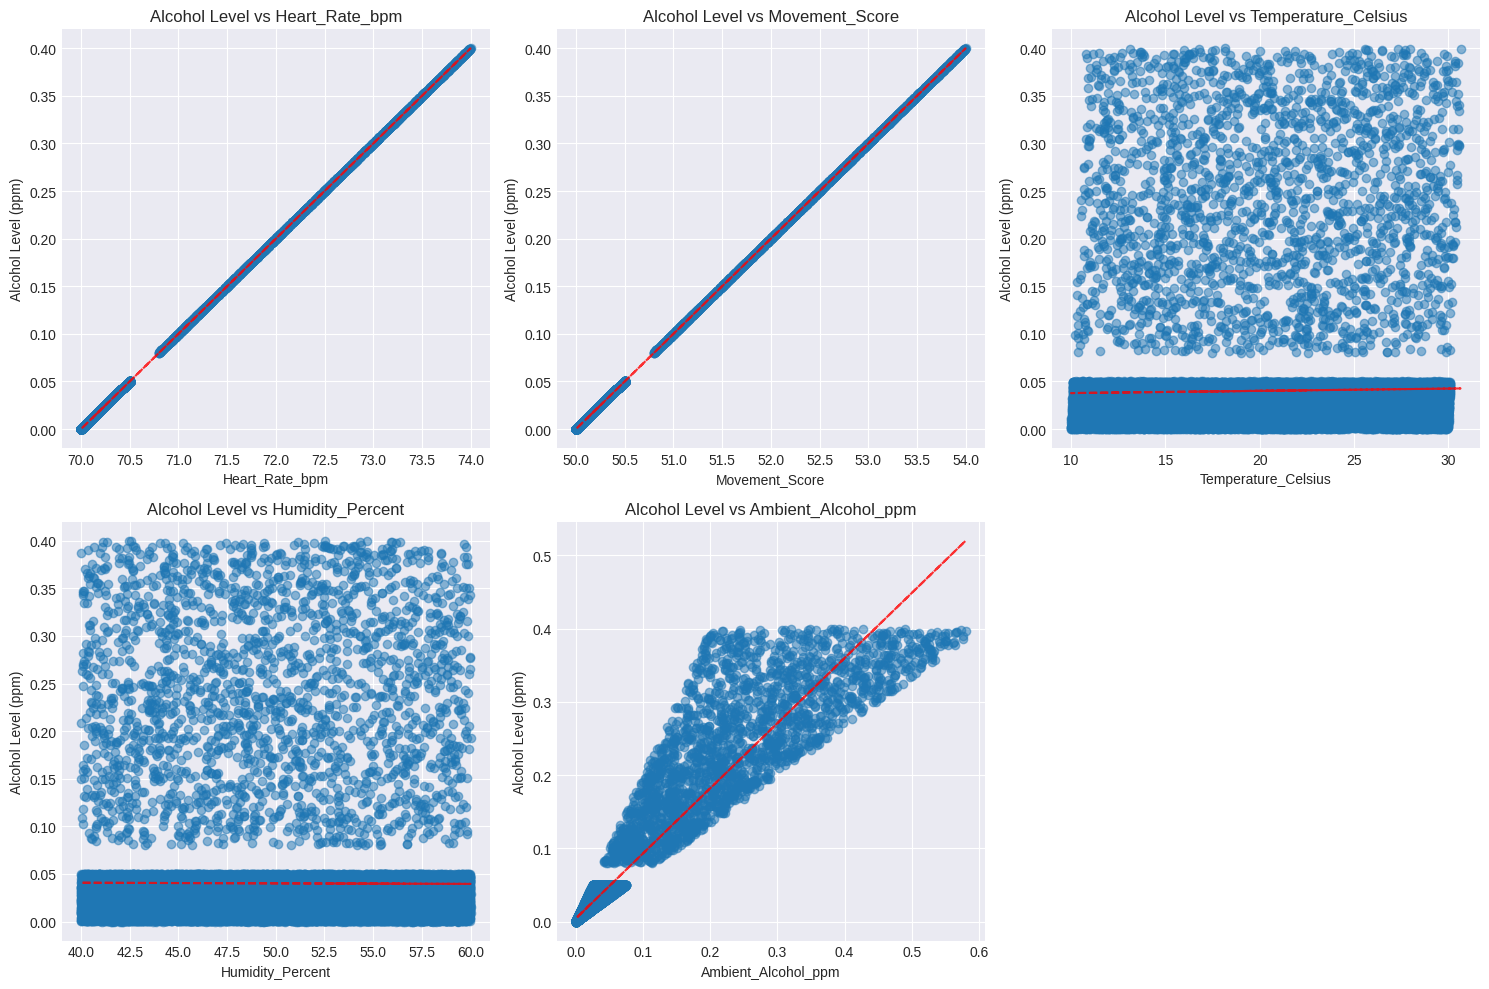

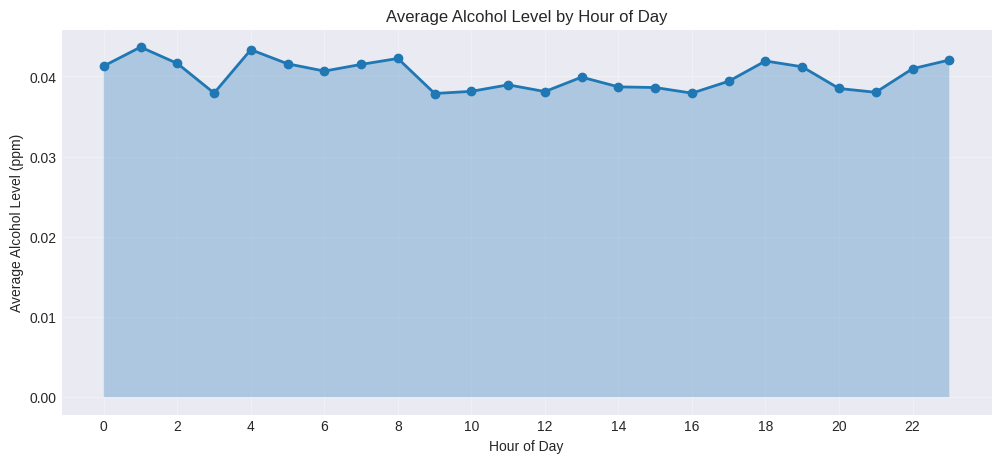


FEATURE ENGINEERING
Original features: 6
Total features after engineering: 24

New features created:
['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'TimeOfDay', 'Driver_Avg_Alcohol', 'Driver_Std_Alcohol', 'Driver_Max_Alcohol', 'Driver_Avg_HeartRate', 'Driver_Std_HeartRate', 'Driver_Avg_Movement', 'Temp_Humidity_Interaction', 'HeartRate_Movement_Ratio', 'Alcohol_Ratio', 'Recent_Avg_Alcohol', 'Is_Intoxicated']

DATA PREPROCESSING
Missing values in features: 0
Final feature matrix shape: (30000, 23)
Target variable shape: (30000,)

TRAIN-TEST SPLIT
Training set size: 24000 samples
Test set size: 6000 samples
Training features: 23

Temporal range in training: First 2025-01-01 00:08:00 to Last 2025-05-25 15:38:00
Temporal range in testing: First 2025-05-25 15:39:00 to Last 2025-06-29 23:54:00

MODEL TRAINING AND EVALUATION

Training Linear Regression...
  Train RMSE: 0.0000, Test RMSE: 0.0000
  Train R²: 1.0000, Test R²: 1.0000
  Train MAE: 0.0000, Test MAE: 0.0000

Training Ridge Regression.

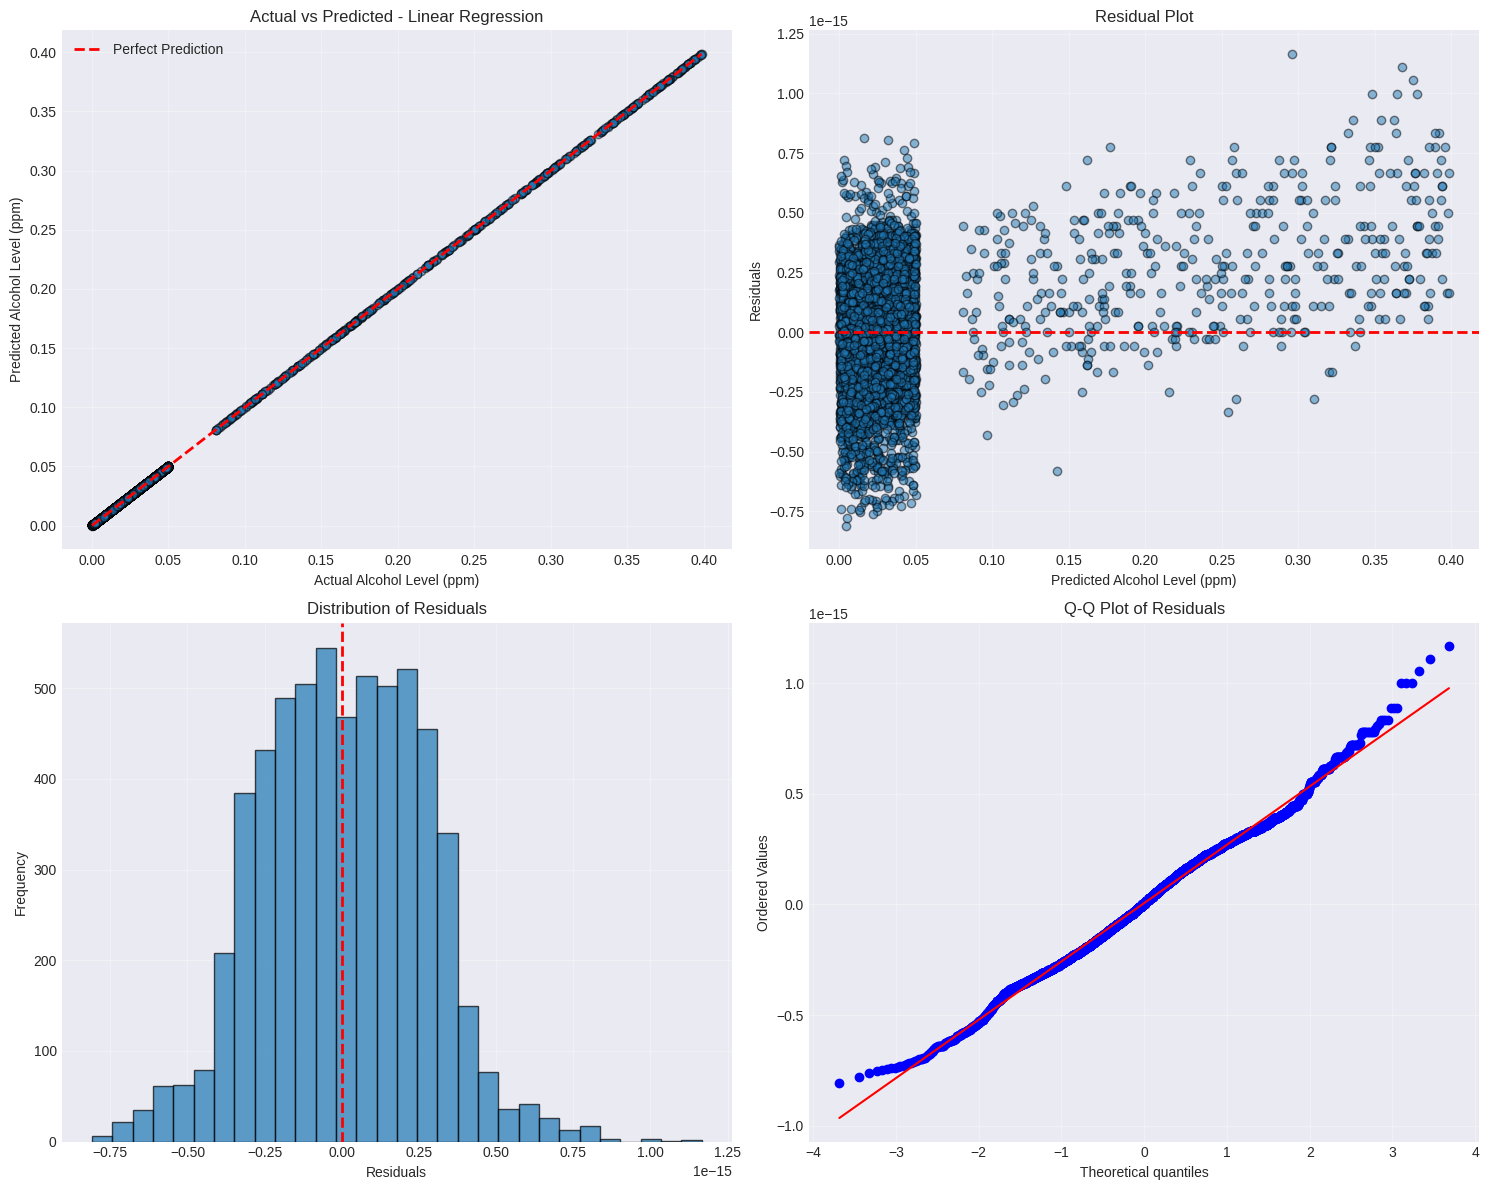

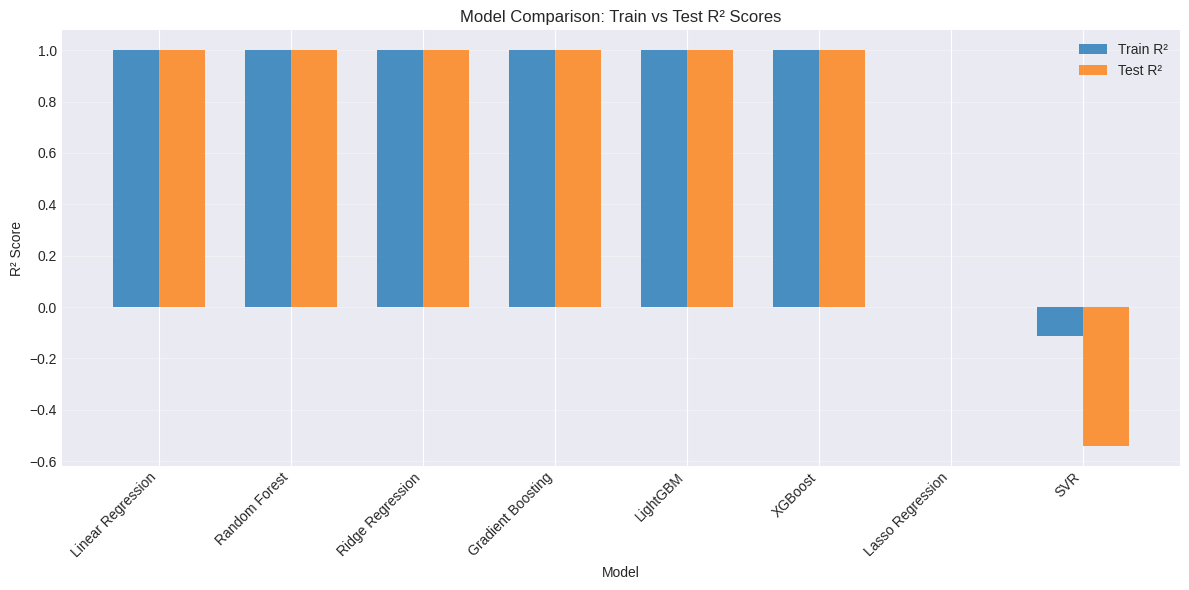

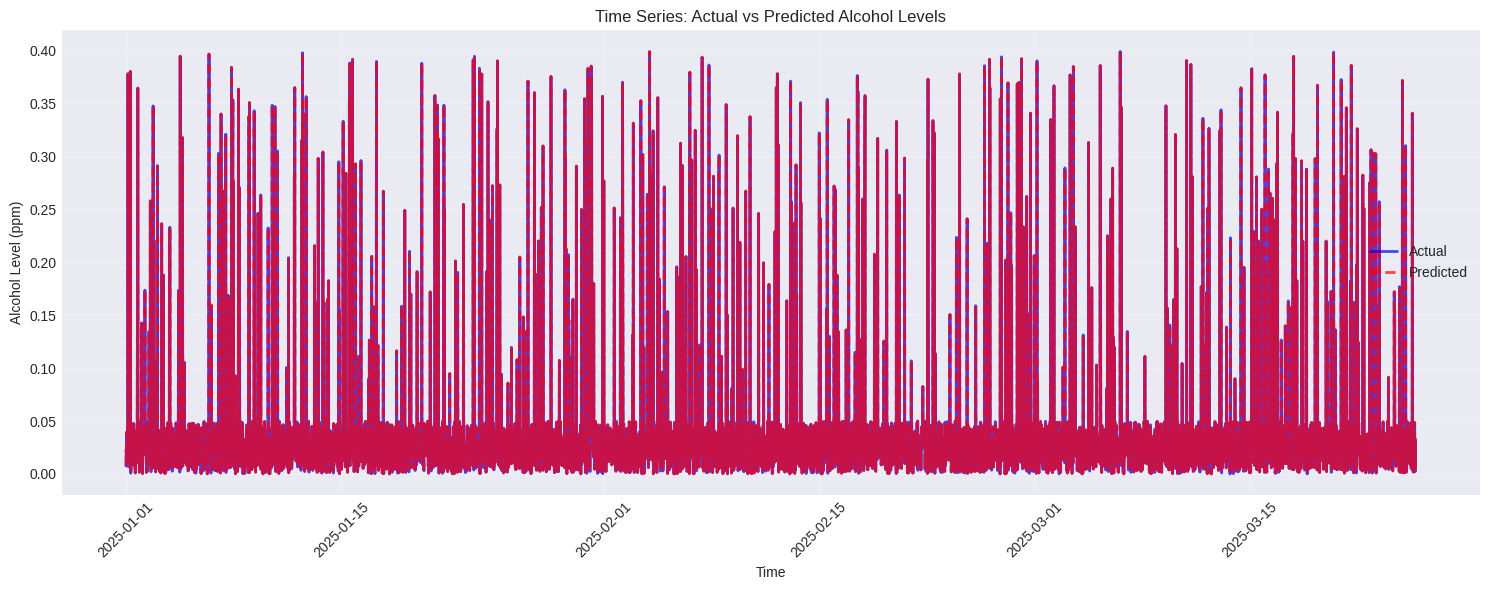

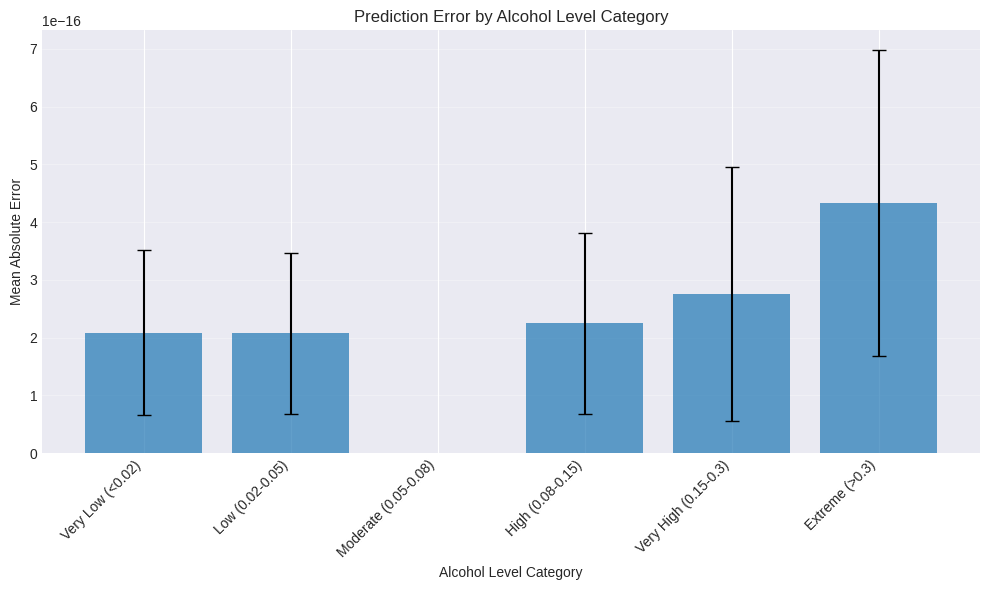


ENSEMBLE MODEL CHECK
Best Individual Model Performance:
  Test R²: 1.0000
  Overfitting Ratio: 0.9945
  Accuracy Threshold (R²): 0.85
  Overfitting Threshold: 0.9

✅ Individual model performance is already good!
   R² (1.0000) ≥ threshold (0.85)
   Overfitting ratio (0.9945) ≥ threshold (0.9)
   Skipping ensemble modeling to avoid complexity

MODEL DEPLOYMENT
✅ Model package saved as: alcohol_detection_model.pkl
✅ Scaler saved separately as: alcohol_detection_model_scaler.pkl
Best model type: LinearRegression
Ensemble model: Not included
Total models in deployment: 1 (best model only)
Number of features: 23
Training date: 2026-01-02 19:33:04

Example prediction function saved in code comments

BUSINESS INSIGHTS AND RECOMMENDATIONS

1. MODEL PERFORMANCE INSIGHTS:
   • Best performing model:  Linear Regression
   • Test R² score: 1.000
   • Test RMSE: 0.0000 ppm

3. SAFETY THRESHOLD ANALYSIS (>0.08 ppm):
   • Classification accuracy: 100.0%
   • False negatives (missed intoxications): 0

In [102]:
def run_complete_pipeline(file_path='alcohol_detection_dataset.csv'):
    """Run the complete alcohol detection pipeline"""
    
    print("=" * 80)
    print("ALCOHOL DETECTION MACHINE LEARNING PIPELINE")
    print("=" * 80)
    
    start_time = datetime.now()
    
    # 1. Load data
    df = load_data(file_path)
    
    # 2. EDA
    df = exploratory_data_analysis(df)
    
    # 3. Feature Engineering
    df = feature_engineering(df)
    
    # 4. Preprocessing
    X, y, y_class, feature_cols, scaler = preprocess_data(df)
    
    # 5. Train-test split
    X_train, X_test, y_train, y_test = create_train_test_split(X, y)
    
    # 6. Model training - now returns 5 values
    results, results_df, best_model, best_model_name, needs_tuning = train_and_evaluate_models(X_train, X_test, y_train, y_test)
    
    # 7. Hyperparameter tuning - updated to use the new function signature
    # Get current model performance metrics
    current_test_r2 = results[best_model_name]['test_r2']
    current_overfitting_ratio = results[best_model_name]['overfitting_ratio']
    
    # Call the updated hyperparameter_tuning function
    best_model = hyperparameter_tuning(
        X_train, X_test, y_train, y_test, 
        best_model, best_model_name, 
        current_test_r2, current_overfitting_ratio
    )
    
    # 8. Model analysis - updated to include model_name parameter
    analyze_model(best_model, best_model_name, X_train, feature_cols)
    
    # 9. Visualization
    visualize_results(results, y_test, best_model, X_test)
    
    # 10. Ensemble (optional) - updated to use the new function signature
    ensemble_model = create_ensemble_model(
        X_train, y_train, X_test, y_test, 
        current_test_r2, current_overfitting_ratio
    )
    
    # 11. Deployment - updated to include ensemble_model parameter
    deployment_package = deploy_model(best_model, scaler, feature_cols, ensemble_model)
    
    # 12. Business insights
    business_insights = generate_business_insights(results_df, df, feature_cols, best_model)
    
    end_time = datetime.now()
    duration = end_time - start_time
    
    print("\n" + "=" * 80)
    print("PIPELINE COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    print(f"Total execution time: {duration}")
    print(f"Best model: {best_model_name}")
    print(f"Best test R²: {current_test_r2:.4f}")
    print(f"Model saved as: alcohol_detection_model.pkl")
    print(f"Scaler saved as: alcohol_detection_model_scaler.pkl")
    print("\nReady for production deployment!")
    
    return {
        'data': df,
        'models': results,
        'best_model': best_model,
        'best_model_name': best_model_name,
        'ensemble_model': ensemble_model,
        'deployment': deployment_package,
        'insights': business_insights
    }

# Run the complete pipeline
if __name__ == "__main__":
    pipeline_results = run_complete_pipeline('/kaggle/input/alcohol-detection-dataset/alcohol_detection_dataset.csv')

# 15. Usage Instructions

In [103]:
"""
USAGE INSTRUCTIONS:

1. Save this entire code as a Python file (e.g., alcohol_detection_pipeline.py)

2. Run the complete pipeline:
   python alcohol_detection_pipeline.py

3. Or run sections individually:
   - For quick analysis: Sections 1-4 (EDA and Feature Engineering)
   - For modeling: Sections 5-8 (Preprocessing, Training, Tuning)
   - For deployment: Sections 10-12 (Visualization, Deployment, Insights)

4. To make predictions with new data:

   # Load the saved model
   import joblib
   deployment_package = joblib.load('alcohol_detection_model.pkl')
   
   # Prepare new data (must have all engineered features)
   new_data = pd.DataFrame({
       'Heart_Rate_bpm': [75],
       'Movement_Score': [52],
       'Temperature_Celsius': [22.5],
       'Humidity_Percent': [55.0],
       'Ambient_Alcohol_ppm': [0.015],
       # ... include all other features from feature_cols
   })
   
   # Make prediction
   model = deployment_package['model']
   scaler = deployment_package['scaler']
   
   # Scale features
   new_data_scaled = scaler.transform(new_data[deployment_package['feature_columns']])
   
   # Predict
   prediction = model.predict(new_data_scaled)
   print(f"Predicted alcohol level: {prediction[0]:.4f} ppm")
   
   # Check if above legal limit
   if prediction[0] > 0.08:
       print("⚠️ WARNING: Predicted above legal limit!")

KEY FEATURES:
- Complete end-to-end pipeline
- Multiple model comparison
- Hyperparameter optimization
- Feature importance analysis
- Business insights generation
- Production-ready model saving
- Comprehensive visualizations
- Time-series aware splitting
- Ensemble modeling option
"""

'\nUSAGE INSTRUCTIONS:\n\n1. Save this entire code as a Python file (e.g., alcohol_detection_pipeline.py)\n\n2. Run the complete pipeline:\n   python alcohol_detection_pipeline.py\n\n3. Or run sections individually:\n   - For quick analysis: Sections 1-4 (EDA and Feature Engineering)\n   - For modeling: Sections 5-8 (Preprocessing, Training, Tuning)\n   - For deployment: Sections 10-12 (Visualization, Deployment, Insights)\n\n4. To make predictions with new data:\n\n   # Load the saved model\n   import joblib\n   deployment_package = joblib.load(\'alcohol_detection_model.pkl\')\n   \n   # Prepare new data (must have all engineered features)\n   new_data = pd.DataFrame({\n       \'Heart_Rate_bpm\': [75],\n       \'Movement_Score\': [52],\n       \'Temperature_Celsius\': [22.5],\n       \'Humidity_Percent\': [55.0],\n       \'Ambient_Alcohol_ppm\': [0.015],\n       # ... include all other features from feature_cols\n   })\n   \n   # Make prediction\n   model = deployment_package[\'model\